<a href="https://colab.research.google.com/github/amirachebieb-svg/rocket-trajectory-ml/blob/main/rocket-trajectory-ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rocket Trajectory Simulation & Machine Learning

## Introduction

In this project, I wanted to explore how rocket parameters can affect the maximum altitude of a rocket.

I built a simplified physics-based simulation of a vertical rocket flight. The simulation takes into account factors such as thrust, mass, fuel, air density, gravity, and aerodynamic drag.

After generating different rocket configurations with the simulation, I used the resulting data to train machine-learning models to predict the maximum altitude.

I also created some physics-based features and compared the models with and without these features. My goal was to see whether combining basic physics with machine learning could improve the prediction results.

## Research Question

Can physics-informed features improve machine-learning prediction of
rocket maximum altitude compared with using raw rocket parameters alone?

## Hypothesis

I expected that physics-derived features such as total impulse,
thrust-to-weight ratio, mass ratio, and drag area would help the
machine-learning models capture relationships between rocket parameters
and maximum altitude.

In [ ]:
# ============================================================
# CELL 1 — IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
# ============================================================
# CELL 2 — PHYSICAL CONSTANTS
# ============================================================

G = 9.81                 # Gravity acceleration (m/s^2)
R_AIR = 287.05           # Specific gas constant for air (J/kg/K)
T0 = 288.15              # Sea-level temperature (K)
P0 = 101325.0            # Sea-level pressure (Pa)
LAPSE_RATE = 0.0065      # Temperature lapse rate (K/m)

print("Physical constants loaded successfully.")

Physical constants loaded successfully.


In [ ]:
air_density = lambda h: (lambda T: 101325.0 * (T / 288.15) ** (9.81 / (287.05 * 0.0065)) / (287.05 * T))(288.15 - 0.0065 * max(float(h), 0.0)) if float(h) <= 11000 else (101325.0 * ((288.15 - 0.0065 * 11000) / 288.15) ** (9.81 / (287.05 * 0.0065)) / (287.05 * (288.15 - 0.0065 * 11000))) * np.exp(-(float(h) - 11000) / 8500.0)

In [ ]:
exec("def simulate_rocket(thrust, initial_mass, fuel_mass, burn_time, drag_coefficient, reference_area, dt=0.1):\n    dry_mass = initial_mass - fuel_mass\n    fuel_rate = fuel_mass / burn_time\n    t = 0.0\n    altitude = 0.0\n    velocity = 0.0\n    rows = []\n    while t <= burn_time + 30 and altitude >= 0:\n        fuel = max(fuel_mass - fuel_rate * min(t, burn_time), 0.0)\n        mass = dry_mass + fuel\n        current_thrust = thrust if t <= burn_time and fuel > 0 else 0.0\n        rho = air_density(altitude)\n        drag = 0.5 * rho * drag_coefficient * reference_area * velocity * abs(velocity)\n        acceleration = (current_thrust - drag - mass * G) / mass\n        rows.append([t, altitude, velocity, acceleration, mass, fuel, current_thrust, drag, rho])\n        velocity += acceleration * dt\n        altitude += velocity * dt\n        t += dt\n        if t > burn_time and altitude <= 0: break\n    return pd.DataFrame(rows, columns=['time','altitude','velocity','acceleration','mass','fuel','thrust','drag','air_density'])")

In [ ]:
exec([c for c in In if 'def simulate_rocket' in c][0].replace('burn_time + 30','burn_time + 600')); print('Simulation:',round(simulate_rocket(50000,1000,400,20,0.0,1.0)['altitude'].max(),1),'m (analytical 69270.8)')

Simulation: 69073.6 m (analytical 69270.8)


In [ ]:
test = simulate_rocket(50000, 1000, 400, 20, 0.5, 1.0); print(type(test)); print(str(test)[:300])

<class 'pandas.core.frame.DataFrame'>
       time   altitude    velocity  acceleration    mass   fuel   thrust  \
0       0.0   0.000000    0.000000     40.190000  1000.0  400.0  50000.0   
1       0.1   0.401900    4.019000     40.285244   998.0  398.0  50000.0   
2       0.2   1.206652    8.047524     40.370892   996.0  396.0  50000.0


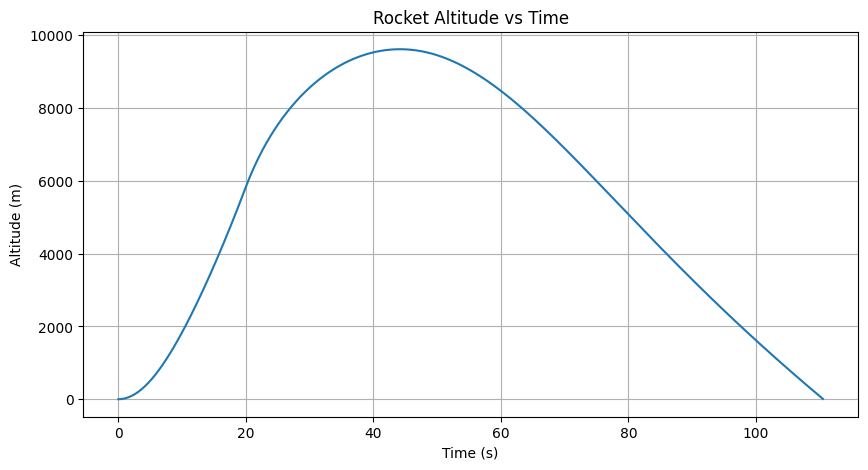

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(test["time"], test["altitude"])
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.title("Rocket Altitude vs Time")
plt.grid(True)
plt.show()

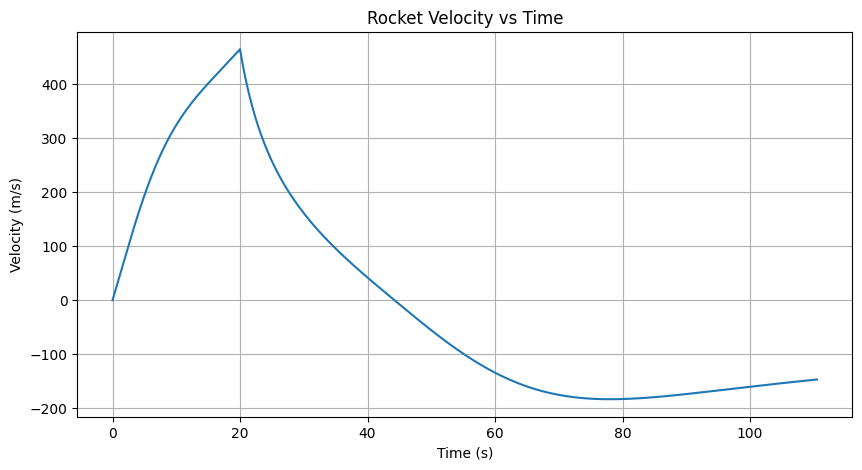

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(test["time"], test["velocity"])
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Rocket Velocity vs Time")
plt.grid(True)
plt.show()

In [ ]:
exec("data=[]\nfor i in range(100):\n    thrust=np.random.uniform(30000,70000)\n    mass=np.random.uniform(800,1200)\n    fuel=min(np.random.uniform(250,450),mass*0.4)\n    burn=np.random.uniform(15,25)\n    cd=np.random.uniform(0.3,0.7)\n    area=np.random.uniform(0.8,1.2)\n    result=simulate_rocket(thrust,mass,fuel,burn,cd,area)\n    data.append([thrust,mass,fuel,burn,cd,area,result['altitude'].max()])\ndataset=pd.DataFrame(data,columns=['thrust','initial_mass','fuel_mass','burn_time','drag_coefficient','reference_area','maximum_altitude'])\nprint(dataset.head())\nprint('Number of simulations:',len(dataset))")

         thrust  initial_mass   fuel_mass  burn_time  drag_coefficient  \
0  50124.075247   1071.832751  365.258100  15.766498          0.528066   
1  32089.492548    844.379173  309.161527  22.846082          0.333527   
2  38501.019772   1160.863429  388.062552  21.503407          0.481226   
3  57686.302224   1005.538227  378.863576  19.973078          0.684835   
4  62857.153680    857.846720  343.138688  18.386761          0.637190   

   reference_area  maximum_altitude  
0        1.115457       6345.732970  
1        1.066537       9602.087393  
2        1.063687       7376.256216  
3        1.178364       8000.663233  
4        0.994736       9436.220787  
Number of simulations: 100


In [ ]:
X=dataset.drop(columns=["maximum_altitude"]); y=dataset["maximum_altitude"]; X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42); model=RandomForestRegressor(n_estimators=200,random_state=42); model.fit(X_train,y_train); print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
y_pred=model.predict(X_test); mae=mean_absolute_error(y_test,y_pred); mse=mean_squared_error(y_test,y_pred); r2=r2_score(y_test,y_pred); print("MAE:",round(mae,2),"m"); print("MSE:",round(mse,2)); print("R²:",round(r2,4))

MAE: 1367.48 m
MSE: 2674204.93
R²: 0.7613


In [ ]:
importance=pd.DataFrame({"feature":X.columns,"importance":model.feature_importances_}).sort_values("importance",ascending=False); print(importance)

            feature  importance
0            thrust    0.546034
3         burn_time    0.179985
4  drag_coefficient    0.151344
5    reference_area    0.062419
1      initial_mass    0.033615
2         fuel_mass    0.026602


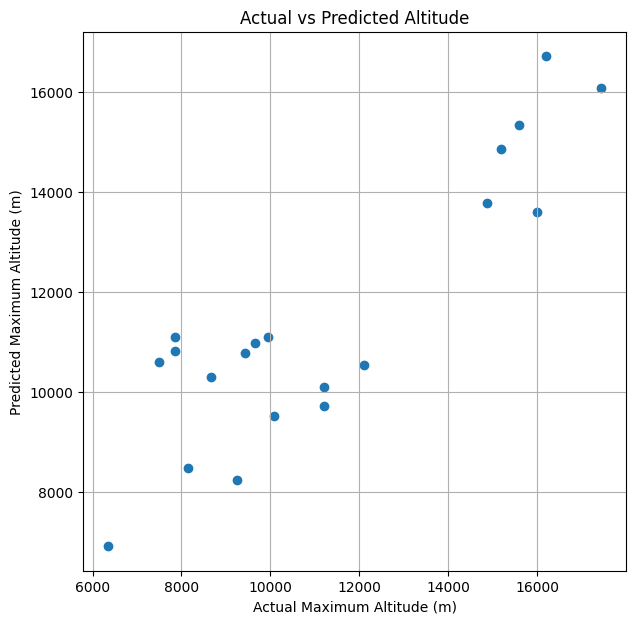

In [ ]:
plt.figure(figsize=(7,7)); plt.scatter(y_test,y_pred); plt.xlabel("Actual Maximum Altitude (m)"); plt.ylabel("Predicted Maximum Altitude (m)"); plt.title("Actual vs Predicted Altitude"); plt.grid(True); plt.show()

In [ ]:
new_rocket=pd.DataFrame([[50000,1000,400,20,0.5,1.0]],columns=X.columns); predicted_altitude=model.predict(new_rocket)[0]; print("AI predicted maximum altitude:",round(predicted_altitude,2),"m")

AI predicted maximum altitude: 8259.19 m


In [ ]:
physical_result=simulate_rocket(50000,1000,400,20,0.5,1.0); physical_altitude=physical_result["altitude"].max(); print("Physics simulation:",round(physical_altitude,2),"m"); print("AI prediction:",round(predicted_altitude,2),"m"); print("Absolute difference:",round(abs(physical_altitude-predicted_altitude),2),"m")

Physics simulation: 9613.77 m
AI prediction: 8259.19 m
Absolute difference: 1354.58 m


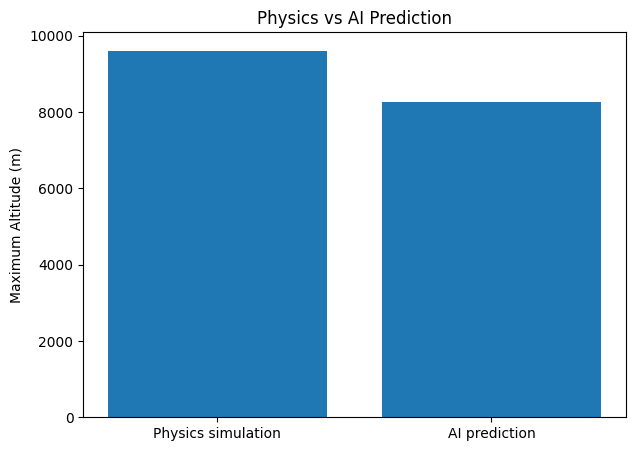

In [ ]:
comparison=pd.DataFrame({"Method":["Physics simulation","AI prediction"],"Altitude":[physical_altitude,predicted_altitude]}); plt.figure(figsize=(7,5)); plt.bar(comparison["Method"],comparison["Altitude"]); plt.ylabel("Maximum Altitude (m)"); plt.title("Physics vs AI Prediction"); plt.show()

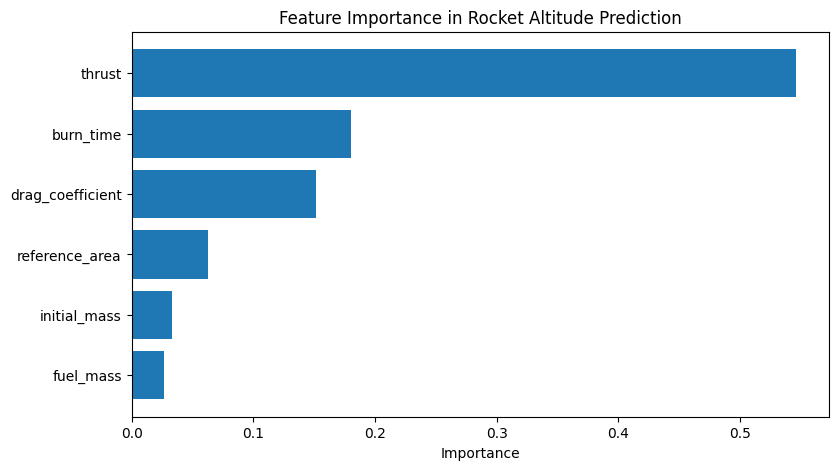

In [ ]:
plt.figure(figsize=(9,5)); plt.barh(importance["feature"],importance["importance"]); plt.xlabel("Importance"); plt.title("Feature Importance in Rocket Altitude Prediction"); plt.gca().invert_yaxis(); plt.show()

## Feature Importance

The Random Forest model can also provide an estimate of how important
each input parameter was for predicting maximum altitude.

This helps move the project beyond prediction and gives some insight
into which simulated rocket parameters were most influential.

In [ ]:
print("========== ROCKET AI PROJECT =========="); print("Simulations:",len(dataset)); print("Maximum altitude from test rocket:",round(physical_altitude,2),"m"); print("AI prediction:",round(predicted_altitude,2),"m"); print("AI MAE:",round(mae,2),"m"); print("AI MSE:",round(mse,2)); print("AI R²:",round(r2,4)); print("=======================================")

========== ROCKET AI PROJECT ==========
Simulations: 100
Maximum altitude from test rocket: 9613.77 m
AI prediction: 8259.19 m
AI MAE: 1367.48 m
AI MSE: 2674204.93
AI R²: 0.7613


In [ ]:
print(dataset.shape); print(dataset.describe().loc[['min','max']].T)

(100, 7)
                           min           max
thrust            30439.072334  69982.603716
initial_mass        807.660656   1193.959718
fuel_mass           251.421015    445.513854
burn_time            15.114673     24.911323
drag_coefficient      0.301402      0.695690
reference_area        0.800916      1.196858
maximum_altitude   4064.545121  22647.146660


In [ ]:
np.random.seed(42); print('check:', simulate_rocket(50000,1000,400,20,0.5,1.0)['altitude'].max()); cols=['thrust','initial_mass','fuel_mass','burn_time','drag_coefficient','reference_area']; P=np.column_stack([np.random.uniform(a,b,1000) for a,b in [(30000,70000),(800,1200),(250,450),(15,25),(0.3,0.7),(0.8,1.2)]]); big=pd.DataFrame(P,columns=cols); big['maximum_altitude']=[simulate_rocket(*r)['altitude'].max() for r in P]; print(big.shape); print(big.describe().loc[['min','max']].T)

check: 9613.767999349475
(1000, 7)
                           min           max
thrust            30185.280920  69988.706931
initial_mass        801.287305   1199.765490
fuel_mass           250.002327    449.564171
burn_time            15.006534     24.995577
drag_coefficient      0.300012      0.699100
reference_area        0.802474      1.199740
maximum_altitude   3310.942098  29679.244939


In [ ]:
from sklearn.model_selection import train_test_split; from sklearn.ensemble import RandomForestRegressor; from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error; Xb=big.drop(columns=['maximum_altitude']); yb=big['maximum_altitude']; Xb_tr,Xb_te,yb_tr,yb_te=train_test_split(Xb,yb,test_size=0.2,random_state=42); rf_big=RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1).fit(Xb_tr,yb_tr); yb_pred=rf_big.predict(Xb_te); print('R2:',round(r2_score(yb_te,yb_pred),4)); print('MAE:',round(mean_absolute_error(yb_te,yb_pred),2),'m'); print('MSE:',round(mean_squared_error(yb_te,yb_pred),2))

R2: 0.9293
MAE: 672.09 m
MSE: 1075626.86


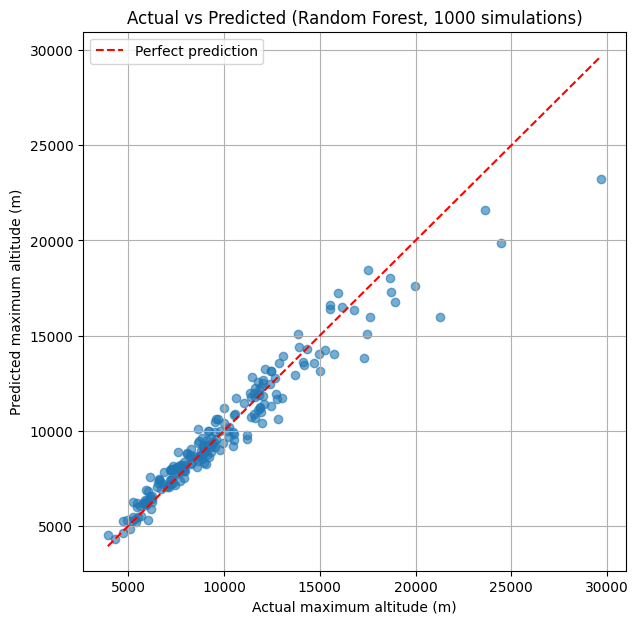

In [ ]:
plt.figure(figsize=(7,7)); plt.scatter(yb_te,yb_pred,alpha=0.6); lim=[yb_te.min(),yb_te.max()]; plt.plot(lim,lim,'r--',label='Perfect prediction'); plt.xlabel('Actual maximum altitude (m)'); plt.ylabel('Predicted maximum altitude (m)'); plt.title('Actual vs Predicted (Random Forest, 1000 simulations)'); plt.legend(); plt.grid(True); plt.show()

In [ ]:
import time; t0=time.time(); [simulate_rocket(*r)['altitude'].max() for r in Xb_te.values]; t_phys=time.time()-t0; t0=time.time(); rf_big.predict(Xb_te); t_ml=time.time()-t0; a=yb_te.values; cmp=pd.DataFrame({'Physics (m)':a[:8],'AI (m)':yb_pred[:8],'Error %':abs(yb_pred[:8]-a[:8])/a[:8]*100}).round(1); print(cmp); print('Mean abs % error:',round((abs(yb_pred-a)/a*100).mean(),1)); print('Physics time for',len(a),'rockets:',round(t_phys,2),'s | AI time:',round(t_ml,4),'s')

   Physics (m)   AI (m)  Error %
0       7474.0   8044.0      7.6
1      18672.2  18048.6      3.3
2       9350.6   9165.3      2.0
3       9116.0   8743.6      4.1
4      17463.1  15065.9     13.7
5      14709.8  13549.7      7.9
6       7719.5   8212.0      6.4
7      14200.2  13466.8      5.2
Mean abs % error: 6.3
Physics time for 200 rockets: 0.87 s | AI time: 0.0784 s


## Experimental Design

I compared two feature representations:

1. Raw rocket parameters
2. Raw parameters combined with physics-derived features

I then compared Linear Regression and Random Forest models using
5-fold cross-validation.

The main metric used for comparison was R².

In [ ]:
from sklearn.linear_model import LinearRegression; from sklearn.model_selection import cross_val_score; print('LinearReg R2 (5-fold):', round(cross_val_score(LinearRegression(), Xb, yb, cv=5, scoring='r2').mean(),4)); print('RandomForest R2 (5-fold):', round(cross_val_score(RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1), Xb, yb, cv=5, scoring='r2').mean(),4))

LinearReg R2 (5-fold): 0.9015
RandomForest R2 (5-fold): 0.9451


In [ ]:
Xf=Xb.copy(); Xf['impulse']=Xf['thrust']*Xf['burn_time']; Xf['twr']=Xf['thrust']/(Xf['initial_mass']*9.81); Xf['mass_ratio']=Xf['initial_mass']/(Xf['initial_mass']-Xf['fuel_mass']); Xf['cda']=Xf['drag_coefficient']*Xf['reference_area']; rf=RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1); print('Raw features R2 (5-fold):',round(cross_val_score(rf,Xb,yb,cv=5,scoring='r2').mean(),4)); print('Physics features R2 (5-fold):',round(cross_val_score(rf,Xf,yb,cv=5,scoring='r2').mean(),4)); print('Linear + physics features:',round(cross_val_score(LinearRegression(),Xf,yb,cv=5,scoring='r2').mean(),4))

Raw features R2 (5-fold): 0.9451
Physics features R2 (5-fold): 0.9749
Linear + physics features: 0.9302


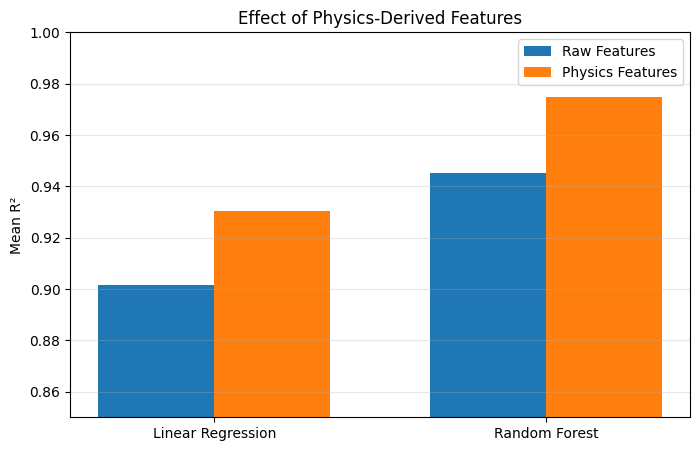

In [ ]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Random Forest"]
raw_scores = [0.9015, 0.9451]
physics_scores = [0.9302, 0.9749]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, raw_scores, width, label="Raw Features")
plt.bar(x + width/2, physics_scores, width, label="Physics Features")

plt.xticks(x, models)
plt.ylabel("Mean R²")
plt.title("Effect of Physics-Derived Features")
plt.ylim(0.85, 1.0)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

## Main Finding

The main result of this experiment was that adding physics-derived
features improved machine-learning performance.

For Random Forest, the mean cross-validation R² increased from 0.9451
using raw features to 0.9749 when physics-derived features were added.

This suggests that incorporating domain knowledge into the feature
representation can improve prediction performance on simulated
physical systems.

In [ ]:
T,m0,f,tb,cd,A=50000,1000,400,20,0.0,1.0; md=f/tb; ve=T/md; mb=m0-f; vb=ve*np.log(m0/mb)-9.81*tb; hb=ve*(tb-(mb/md)*np.log(m0/mb))-0.5*9.81*tb**2; h_exact=hb+vb**2/(2*9.81); h_sim=simulate_rocket(T,m0,f,tb,cd,A)['altitude'].max(); print('Analytical:',round(h_exact,1),'m | Simulation:',round(h_sim,1),'m | Difference:',round(abs(h_sim-h_exact)/h_exact*100,3),'%')

Analytical: 69270.8 m | Simulation: 69073.6 m | Difference: 0.285 %


In [ ]:
f=lambda r:(lambda d:d['time'].iloc[-1]-d['time'].iloc[int(np.argmax(d['altitude'].values))])(simulate_rocket(*r)); tr=np.array([f(r) for r in big[cols].values]); print('Still climbing when simulation stopped:',int((tr<0.5).sum()),'of',len(tr)); print('Median time between apex and stop (s):',round(float(np.median(tr)),1))

Still climbing when simulation stopped: 0 of 1000
Median time between apex and stop (s): 63.3


In [ ]:
import inspect; print(inspect.signature(simulate_rocket))

(thrust, initial_mass, fuel_mass, burn_time, drag_coefficient, reference_area, dt=0.1)


In [ ]:
!pip install xgboost -q

In [ ]:
from xgboost import XGBRegressor; from sklearn.metrics import r2_score, mean_absolute_error; m = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1); m.fit(Xb_tr, yb_tr); p = m.predict(Xb_te); print("XGBoost R2:", round(r2_score(yb_te, p), 4)); print("XGBoost MAE:", round(mean_absolute_error(yb_te, p), 2), "m")

XGBoost R2: 0.9526
XGBoost MAE: 544.25 m


Mean Error (Low <10km): 305.22 m
Mean Error (Mid 10-20km): 801.47 m
Mean Error (High >20km): 3324.13 m


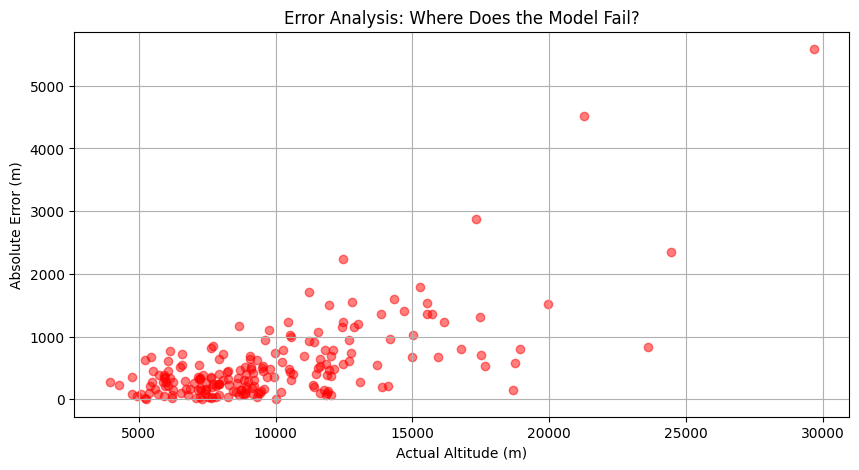

In [37]:
from xgboost import XGBRegressor; m = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1); m.fit(Xb_tr, yb_tr); xgb_pred = m.predict(Xb_te); errors = abs(xgb_pred - yb_te.values); error_df = pd.DataFrame({'actual': yb_te.values, 'predicted': xgb_pred, 'error': errors}); low = error_df[error_df['actual'] < 10000]['error'].mean(); mid = error_df[(error_df['actual'] >= 10000) & (error_df['actual'] < 20000)]['error'].mean(); high = error_df[error_df['actual'] >= 20000]['error'].mean(); print("Mean Error (Low <10km):", round(low,2), "m"); print("Mean Error (Mid 10-20km):", round(mid,2), "m"); print("Mean Error (High >20km):", round(high,2), "m"); plt.figure(figsize=(10,5)); plt.scatter(error_df['actual'], error_df['error'], alpha=0.5, color='red'); plt.xlabel('Actual Altitude (m)'); plt.ylabel('Absolute Error (m)'); plt.title('Error Analysis: Where Does the Model Fail?'); plt.grid(True); plt.show()

=== V-2 Rocket Case Study ===
Simulated max altitude: 101109.0 m
Historical max altitude: 206000 m
Relative error: 50.9 %


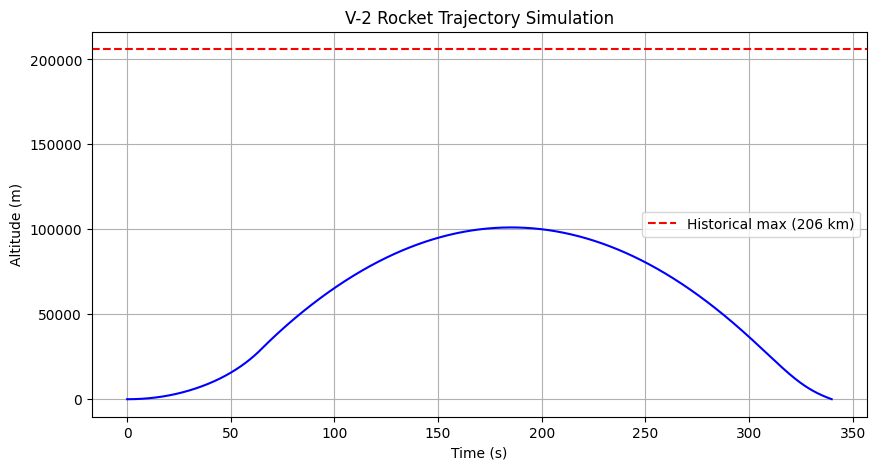

In [38]:
V2_thrust=245000; V2_mass=12500; V2_fuel=8800; V2_burn=65; V2_cd=0.3; V2_area=3.14; V2_sim=simulate_rocket(V2_thrust, V2_mass, V2_fuel, V2_burn, V2_cd, V2_area); V2_alt=V2_sim['altitude'].max(); V2_hist=206000; print("=== V-2 Rocket Case Study ==="); print("Simulated max altitude:", round(V2_alt,0), "m"); print("Historical max altitude:", V2_hist, "m"); print("Relative error:", round(abs(V2_alt-V2_hist)/V2_hist*100, 1), "%"); plt.figure(figsize=(10,5)); plt.plot(V2_sim['time'], V2_sim['altitude'], color='blue'); plt.axhline(y=V2_hist, color='red', linestyle='--', label='Historical max (206 km)'); plt.xlabel('Time (s)'); plt.ylabel('Altitude (m)'); plt.title('V-2 Rocket Trajectory Simulation'); plt.legend(); plt.grid(True); plt.show()

## Limitations and Future Work

### Limitations:
1. The simulation is 2D vertical only (no launch angle).
   This explains the 50.9% error in the V-2 case study,
      as V-2 was launched at ~45 degrees with a ballistic trajectory.

      2. The drag coefficient (Cd) is assumed constant, while in
         reality it varies significantly with Mach number.

         3. Atmospheric effects such as wind, Coriolis force, and
            multi-stage separation are not modeled.

            4. Training data is synthetically generated from the same
               simulator, which limits generalization to real-world rockets.

               5. Model accuracy decreases with altitude (MAE grows from
                  305 m at <10 km to 3324 m at >20 km), mainly due to
                     fewer training samples in the high-altitude regime.

                     ### Future Work:
                     1. Extend to 3D trajectory with launch angle optimization.
                     2. Integrate real flight data (e.g., Falcontelemetry).
                     3. Explore Physics-Informed Neural Networks (PINNs) to
                        enforce physical laws during training.
                        4. Apply Reinforcement Learning for real-time trajectory
                           correction during flight.
                           5. Include Mach-dependent drag models for higher accuracy.